<a href="https://colab.research.google.com/github/dpakkt/current-project/blob/main/datathon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## New Section

Clean dataset

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Social_Science.csv to Social_Science (2).csv


In [ ]:
import pandas as pd
astronaut_df = pd.read_csv('Social_Science.csv')
#df.columns.get_loc('Koch, Christina')
#df_clean = df.drop_duplicates(subset=["Profile.Name"])
# See if any rows are exact duplicates
# See which names repeat
astronaut_df = astronaut_df.drop_duplicates(subset=["Profile.Name"], keep="first")


In [ ]:
astronaut_df = astronaut_df[(astronaut_df['Profile.Nationality'] == 'U.S.') &
        (astronaut_df['Profile.Selection.Year'] > 1969) &
        (astronaut_df['Profile.Selection.Year'] < 2010)]
astronaut_df.describe()

,Profile.Astronaut Numbers.Overall,Profile.Astronaut Numbers.Nationwide,Profile.Birth Year,Profile.Selection.Year,Profile.Lifetime Statistics.Mission count,Mission.Year,Mission.Durations.Mission duration,Profile.Lifetime Statistics.Mission duration,Mission.Durations.EVA duration,Profile.Lifetime Statistics.EVA duration
count,276.000000,276.000000,276.000000,276.000000,276.000000,276.000000,276.000000,276.000000,276.000000,276.000000
mean,320.358696,199.601449,1954.673913,1990.159420,2.630435,1995.554348,495.881286,1612.619801,2.751159,9.256268
std,122.851122,82.725662,8.308299,8.316246,1.340698,9.083088,1002.523426,2275.927735,6.049610,15.236602
min,119.000000,55.000000,1932.000000,1978.000000,1.000000,1978.000000,0.610000,0.610000,0.000000,0.000000
25%,218.750000,129.750000,1949.000000,1984.000000,2.000000,1989.000000,168.000000,382.000000,0.000000,0.000000
50%,313.500000,198.500000,1955.000000,1990.000000,2.000000,1994.000000,236.090000,687.500000,0.000000,0.000000
75%,425.000000,268.500000,1961.000000,1996.000000,4.000000,2002.000000,331.132500,1379.500000,0.000000,13.820000
max,558.000000,343.000000,1978.000000,2009.000000,7.000000,2018.000000,6902.350000,15982.000000,34.600000,67.670000


In [ ]:
astronaut_df["Decade"] = (astronaut_df["Profile.Selection.Year"] // 10) * 10
counts = astronaut_df.groupby(["Decade", "Profile.Gender"]).size().reset_index(name="Count")
totals = counts.groupby("Decade")["Count"].transform("sum")
counts["Percent"] = (counts["Count"] / totals * 100).round(2)
table = counts.pivot(index="Decade", columns="Profile.Gender", values=["Count", "Percent"]).fillna(0)
table.columns = [f"{stat}_{gender}" for stat, gender in table.columns]
print(table)

        Count_female  Count_male  Percent_female  Percent_male
Decade                                                        
1970             6.0        32.0           15.79         84.21
1980            11.0        69.0           13.75         86.25
1990            23.0        98.0           19.01         80.99
2000             7.0        30.0           18.92         81.08


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving final dataset - Sheet1.csv to final dataset - Sheet1 (1).csv


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

compiled_dataset = pd.read_csv('final dataset - Sheet1.csv')
compiled_dataset.describe()

data = {
    'Year': [1970, 1980, 1990, 2000],
    'Female % Astro': ['15.79%', '13.75%', '19.01%', '18.92%'],
    'Female % military': ['1.10%', '8.50%', '11.30%', '14.70%'],
    'Female % STEM': ['7.00%', '14.00%', '23.00%', '25.00%'],
    'White % Astro': ['89.50%', '90.80%', '~85.6%', '86.10%'],
    'White % military': [80, 75, 70, 65],
    'White % STEM': [90, 85, 80, 75],
    'African % Astro': ['7.90%', '3.90%', '~5.4%', '~5.6%'],
    'African American % military': [12, 15, 20, 19],
    'African American % STEM': [10, 10, 10, 12],
    'Asian % Astro': ['2.60%', '3.90%', '~3.6%', '~2.8%'],
    'Asian % military': [2, 2, 2, 2],
    'Asian % STEM': [2, 4, 8, 15],
    'Latino % Astro': ['0%', '1.30%', '~4.5%', '~5.6%'],
    'Latino % military': [4, 5, 6, 11],
    'Latino % STEM': [5, 8, 10, 12]
}

compiled_dataset = pd.DataFrame(data)


#convert percentage strings to numeric
def clean_percent(x):
  if isinstance(x,str):
    x = x.replace('~', '').replace('%','')
    return float(x)
  return x

for col in compiled_dataset.columns[1:]:
  compiled_dataset[col] = compiled_dataset[col].apply(clean_percent)
compiled_dataset

,Year,Female % Astro,Female % military,Female % STEM,White % Astro,White % military,White % STEM,African % Astro,African American % military,African American % STEM,Asian % Astro,Asian % military,Asian % STEM,Latino % Astro,Latino % military,Latino % STEM
0,1970,15.79,1.1,7.0,89.5,80,90,7.9,12,10,2.6,2,2,0.0,4,5
1,1980,13.75,8.5,14.0,90.8,75,85,3.9,15,10,3.9,2,4,1.3,5,8
2,1990,19.01,11.3,23.0,85.6,70,80,5.4,20,10,3.6,2,8,4.5,6,10
3,2000,18.92,14.7,25.0,86.1,65,75,5.6,19,12,2.8,2,15,5.6,11,12


In [ ]:
#trends/differences
compiled_dataset['Female % Astro Change'] = compiled_dataset['Female % Astro'].diff().fillna(0)
compiled_dataset['Female % STEM Change'] = compiled_dataset['Female % STEM'].diff().fillna(0)
compiled_dataset['Female % military Change'] = compiled_dataset['Female % military'].diff().fillna(0)
compiled_dataset

,Year,Female % Astro,Female % military,Female % STEM,White % Astro,White % military,White % STEM,African % Astro,African American % military,African American % STEM,Asian % Astro,Asian % military,Asian % STEM,Latino % Astro,Latino % military,Latino % STEM,Female % Astro Change,Female % STEM Change,Female % military Change
0,1970,15.79,1.1,7.0,89.5,80,90,7.9,12,10,2.6,2,2,0.0,4,5,0.00,0.0,0.0
1,1980,13.75,8.5,14.0,90.8,75,85,3.9,15,10,3.9,2,4,1.3,5,8,-2.04,7.0,7.4
2,1990,19.01,11.3,23.0,85.6,70,80,5.4,20,10,3.6,2,8,4.5,6,10,5.26,9.0,2.8
3,2000,18.92,14.7,25.0,86.1,65,75,5.6,19,12,2.8,2,15,5.6,11,12,-0.09,2.0,3.4


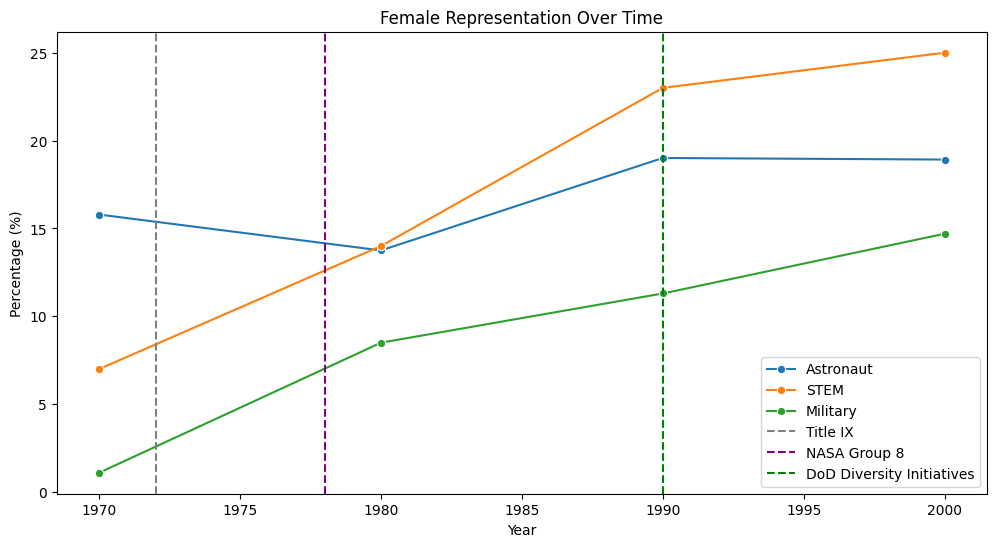

In [ ]:
plt.figure(figsize=(12,6))
sns.lineplot(x='Year', y='Female % Astro', data=compiled_dataset, marker='o', label='Astronaut')
sns.lineplot(x='Year', y='Female % STEM', data=compiled_dataset, marker='o', label='STEM')
sns.lineplot(x='Year', y='Female % military', data=compiled_dataset, marker='o', label='Military')
plt.title('Female Representation Over Time')
plt.ylabel('Percentage (%)')
plt.xlabel('Year')

# Add historical policy events
plt.axvline(1972, color='gray', linestyle='--', label='Title IX')
plt.axvline(1978, color='purple', linestyle='--', label='NASA Group 8')
plt.axvline(1990, color='green', linestyle='--', label='DoD Diversity Initiatives')

plt.legend()
plt.show()


In [ ]:
correlation = compiled_dataset['Female % Astro'].corr(compiled_dataset['Female % STEM'])
print("Correlation between Female Astronauts and STEM workforce:", correlation)

Correlation between Female Astronauts and STEM workforce: 0.7707107516152494


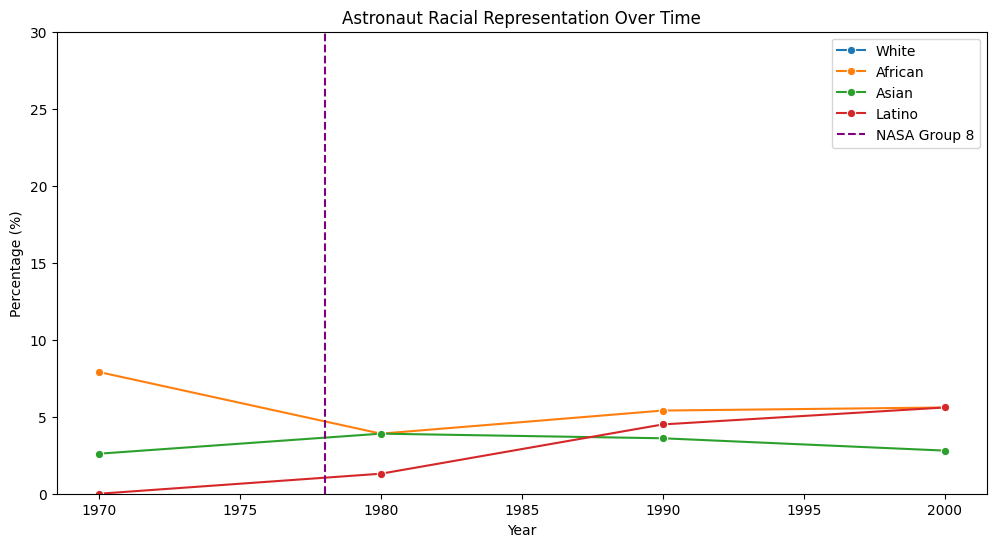

In [ ]:
plt.figure(figsize=(12,6))

sns.lineplot(x='Year', y='White % Astro', data=compiled_dataset, marker='o', label='White')
sns.lineplot(x='Year', y='African % Astro', data=compiled_dataset, marker='o', label='African')
sns.lineplot(x='Year', y='Asian % Astro', data=compiled_dataset, marker='o', label='Asian')
sns.lineplot(x='Year', y='Latino % Astro', data=compiled_dataset, marker='o', label='Latino')



plt.axvline(1978, color='purple', linestyle='--', label='NASA Group 8')
plt.ylim(0, 30)
plt.title('Astronaut Racial Representation Over Time')
plt.xlabel('Year')
plt.ylabel('Percentage (%)')
plt.legend()
plt.show()

In [ ]:
races = ['White', 'African', 'Asian', 'Latino']

for race in races:
    if race == 'African':
        x = compiled_dataset['African American % military']
        y = compiled_dataset[f'{race} % Astro']
    elif race == 'Latino':
        x = compiled_dataset['Latino % military']
        y = compiled_dataset[f'{race} % Astro']
    else:
        x = compiled_dataset[f'{race} % military']
        y = compiled_dataset[f'{race} % Astro']


    corr, p_value = pearsonr(x, y)
    print(f"{race} - correlation: {corr:.2f}, p-value: {p_value:.4f}")

White - correlation: 0.78, p-value: 0.2194
African - correlation: -0.46, p-value: 0.5359
Asian - correlation: nan, p-value: nan
Latino - correlation: 0.85, p-value: 0.1452


/tmp/ipython-input-1039290396.py:15: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p_value = pearsonr(x, y)


In [ ]:
# percent stem
from scipy.stats import pearsonr

races = ['White', 'African', 'Asian', 'Latino']

for race in races:
    # Correct the column name for African STEM
    if race == 'African':
        x = compiled_dataset['African American % STEM']
    else:
        x = compiled_dataset[f'{race} % STEM']

    y = compiled_dataset[f'{race} % Astro']

    if x.nunique() > 1:  # skip constant columns
        corr, p_value = pearsonr(x, y)
        print(f"{race} - correlation: {corr:.2f}, p-value: {p_value:.4f}")
    else:
        print(f"{race} - correlation cannot be computed (constant input)")

White - correlation: 0.78, p-value: 0.2194
African - correlation: -0.04, p-value: 0.9596
Asian - correlation: -0.18, p-value: 0.8207
Latino - correlation: 0.97, p-value: 0.0315
